<a href="https://colab.research.google.com/github/Jeevesh-Bisht/CSE_INTERNSHIP_NVIDIA-20241CSN0029/blob/main/Model_Comparison_CNN_vs_MobileNetV2_vs_ResNet_50_vs_Efficient_NetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow matplotlib pandas

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training Shape: (40000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)

Training CNN...
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.4340 - loss: 1.5519 - val_accuracy: 0.5584 - val_loss: 1.2218
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.5879 - loss: 1.1633 - val_accuracy: 0.6487 - val_loss: 1.0202
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6560 - loss: 0.9775 - val_accuracy: 0.6707 - val_loss: 0.9464
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7056 - loss: 0.8407 - val_accuracy: 0.6939 - val_loss: 0.8905
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7437 - loss: 0.7217 - val_accuracy: 0.6956 - val_loss: 0.9049

Training MobileNetV2...
Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.7106 - loss: 0.8438 - val_accuracy: 0.7806 - val_loss: 0

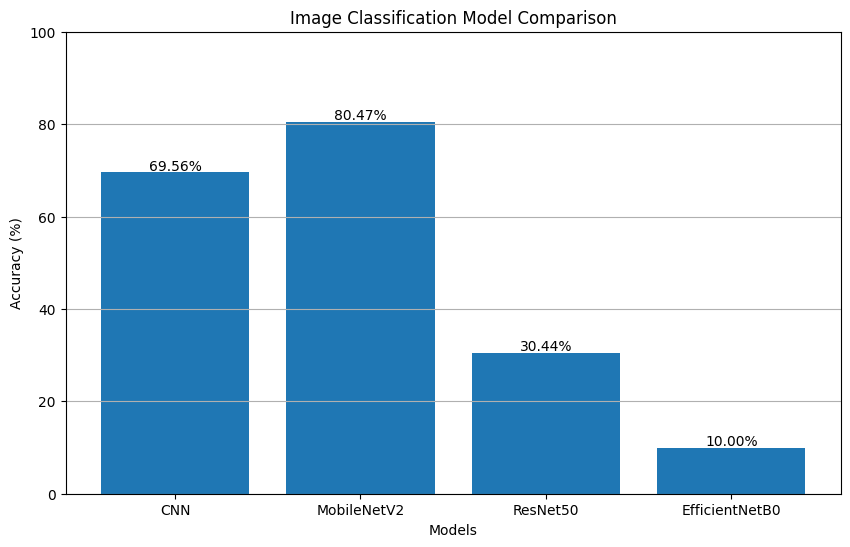


Best Model: MobileNetV2
Best Accuracy: 80.47 %


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train[:40000]
y_train = y_train[:40000]

X_test = X_test[:20000]
y_test = y_test[:20000]

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

results = {}

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

train_pretrained(
    ResNet50,
    "ResNet50"
)

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")

============================
MODEL ACCURACY COMPARISON
============================
CNN             : 55.65%
MobileNetV2     : 77.70%
ResNet50        : 23.20%
EfficientNetB0  : 10.80%

Best Model: MobileNetV2
# Best Accuracy: 77.7 %

X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# ============================
MODEL ACCURACY COMPARISON
============================
CNN             : 69.56%
MobileNetV2     : 80.47%
ResNet50        : 30.44%
EfficientNetB0  : 10.00%


Best Model: MobileNetV2
Best Accuracy: 80.47 %
#UPON CHANGING THE

X_train = X_train[:40000]
y_train = y_train[:40000]

X_test = X_test[:20000]
y_test = y_test[:20000]